# Cloning quasars

In [2]:
import numpy as np
from scipy.stats import norm
from matplotlib import pyplot as plt

In [4]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

data

1479
5.4135
[0.0802     0.346865   0.61353    0.88019496 1.14686    1.413525
 1.68019    1.946855   2.21352    2.480185   2.74685    3.013515
 3.28018    3.546845   3.81351    4.080175   4.34684    4.613505
 4.88017    5.146835   5.4135    ]


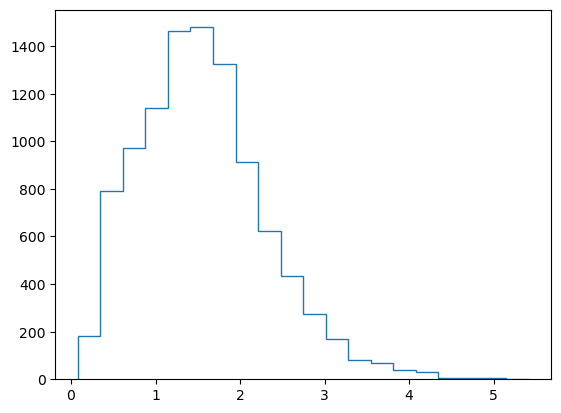

In [5]:
counts, bins = np.histogram(z, bins=20)
plt.stairs(counts, bins)
xmax=np.max(bins)
ymax=np.max(counts)

upsample with rejection sampling

In [23]:
new=[]
while len(new) < 10000:
    x = np.random.uniform(0,xmax)
    for i in range (0,21):
        if (bins[i]<x<bins[i+1]):
            y = np.random.uniform(0,ymax)
            if(y<counts[i]):
                new.append(x)

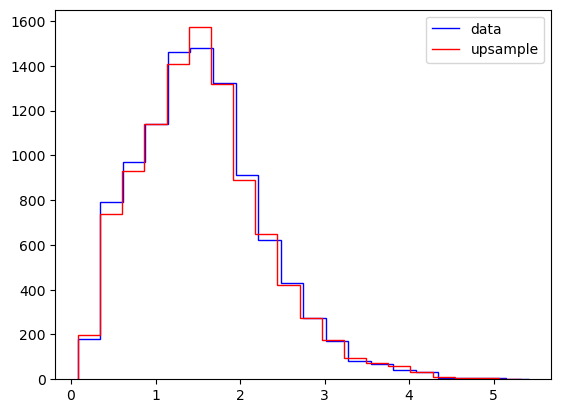

In [24]:
counts_new, bins_new = np.histogram(new, bins=20)
plt.stairs(counts, bins, color='blue', label='data')
plt.stairs(counts_new, bins_new, color='red', label='upsample')
plt.legend()

upsample with inverse transform sampling

In [117]:
cdf=np.cumsum(counts/10000)
cdf

array([0.018 , 0.097 , 0.1941, 0.308 , 0.4542, 0.6021, 0.7344, 0.8256,
       0.8879, 0.9311, 0.9584, 0.9755, 0.9838, 0.9907, 0.9948, 0.9979,
       0.9986, 0.9993, 0.9999, 1.    ])

In [130]:
new=[]

while len(new) < 10000:
    y = np.random.uniform(0,1)
    if y<cdf[0]:
        new.append(bins[0])
    for i in range (0,20):
        if (cdf[i]<y<cdf[i+1]):
            new.append(bins[i+1])

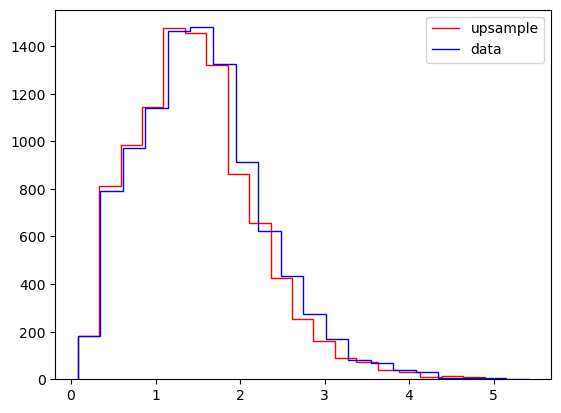

In [131]:
b_new, a_new = np.histogram(new, bins=20)
plt.stairs(b_new, a_new, color='red', label='upsample')
plt.stairs(counts, bins, color='blue', label='data')
plt.legend()